# 🩺 Diagnóstico Preditivo de Câncer de Mama: Estudo Comparativo de Classificadores
**Autor:** Matheus Teixeira  
**Programa:** Pós-Graduação em Ciência de Dados — IFRN  
**Dataset:** [Breast Cancer Wisconsin (Original)](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)  
**Objetivo:** Avaliar o algoritmo de referência *Nearest Centroid* em relação a modelos consolidados de Aprendizado Supervisionado (KNN, Regressão Logística, SVM e Random Forest), priorizando a minimização de falsos negativos (Recall de tumores malignos).

---

## 1. Configuração do Ambiente e Bibliotecas
Importação de pacotes para manipulação de dados, aprendizado de máquina e visualização estatística.

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Configuração visual global
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 10, "figure.autolayout": True})
RANDOM_STATE = 42

## 2. Ingestão e Pré-processamento dos Dados
O dataset original possui atributos celulares extraídos por biópsia aspirativa por agulha fina (PAAF). 
- Removido identificador único (`id`) sem valor preditivo.
- Tratamento de valores ausentes (`?`) na feature `bare_nuclei`.
- Mapeamento das classes: `2 -> Benigno` e `4 -> Maligno`.

In [3]:
COLUMN_NAMES = [
    "id", "clump_thickness", "uniformity_cell_size", "uniformity_cell_shape",
    "marginal_adhesion", "single_epithelial_cell_size", "bare_nuclei",
    "bland_chromatin", "normal_nucleoli", "mitoses", "target"
]

df = pd.read_csv("breast_cancer_wisconsin_original.data", header=None, names=COLUMN_NAMES)

print(f"Dimensões originais: {df.shape[0]} instâncias, {df.shape[1]} colunas.")

# Identificação e tratamento de valores ausentes
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"].replace("?", np.nan), errors="coerce")
n_ausentes = df["bare_nuclei"].isna().sum()

df.dropna(subset=["bare_nuclei"], inplace=True)
df["bare_nuclei"] = df["bare_nuclei"].astype(int)
df.drop(columns=["id"], inplace=True)

# Mapeamento binário: 0 = Benigno (antigo 2), 1 = Maligno (antigo 4)
df["target_bin"] = df["target"].map({2: 0, 4: 1})
class_labels = ["Benigno", "Maligno"]

print(f"Valores ausentes removidos: {n_ausentes}")
print(f"Dimensões finais tratadas: {df.shape[0]} instâncias.")
df["target"].value_counts().rename({2: "Benigno (2)", 4: "Maligno (4)"}).to_frame("Contagem")

Dimensões originais: 696 instâncias, 11 colunas.
Valores ausentes removidos: 16
Dimensões finais tratadas: 680 instâncias.


,Contagem
target,
Benigno (2),441
Maligno (4),239


## 3. Divisão Treino/Teste e Padronização
Garantia de integridade do pipeline contra vazamento de dados (*data leakage*):
- Divisão estratificada (70% treino / 30% teste).
- Padronização Z-score calculada exclusivamente em `X_train` e propagada para `X_test`.

In [4]:
feature_cols = [c for c in df.columns if c not in ["target", "target_bin"]]
X = df[feature_cols].values
y = df["target_bin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Amostras de Treino: {X_train.shape[0]} | Amostras de Teste: {X_test.shape[0]}")

Amostras de Treino: 476 | Amostras de Teste: 204


## 4. Estrutura de Avaliação Multi-Métrica
No contexto oncológico, prever um tumor maligno como benigno (falso negativo) é crítico. Por isso, avaliamos:
- **Acurácia Geral**: percentual de acertos totais.
- **Recall (Sensibilidade) da classe Maligna**: capacidade de detectar pacientes doentes.
- **F1-Score Ponderado**: harmonia entre precisão e sensibilidade.

In [5]:
def benchmark_model(model, X_tr, y_tr, X_te, y_te):
    """Treina e extrai métricas estruturadas de um modelo."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    return {
        "Acurácia": accuracy_score(y_te, y_pred),
        "Precisão (Maligno)": precision_score(y_te, y_pred, pos_label=1),
        "Recall (Maligno)": recall_score(y_te, y_pred, pos_label=1),
        "F1-Score": f1_score(y_te, y_pred, pos_label=1),
        "y_pred": y_pred
    }

## 5. Treinamento e Comparativo de Algoritmos
Abaixo treinamos a bateria de classificadores supervisionados mantendo a reprodutibilidade (`random_state=42`).

In [7]:
classifiers = {
    "Nearest Centroid": NearestCentroid(),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE)
}

results = {}
predictions = {}

for name, clf in classifiers.items():
    res = benchmark_model(clf, X_train_scaled, y_train, X_test_scaled, y_test)
    predictions[name] = res.pop("y_pred")
    results[name] = res

df_results = pd.DataFrame(results).T.sort_values(by=["F1-Score", "Recall (Maligno)"], ascending=False)
df_results.style.format("{:.2%}")

,Acurácia,Precisão (Maligno),Recall (Maligno),F1-Score
Random Forest,98.04%,97.22%,97.22%,97.22%
SVM (RBF),97.55%,97.18%,95.83%,96.50%
Nearest Centroid,97.06%,97.14%,94.44%,95.77%
k-NN (k=5),97.06%,97.14%,94.44%,95.77%
Regressão Logística,97.06%,97.14%,94.44%,95.77%
Árvore de Decisão,95.59%,97.01%,90.28%,93.53%


## 6. Diagnóstico Visual dos Resultados
Comparações gráficas de desempenho e comportamento dos erros nas predições do conjunto de teste.

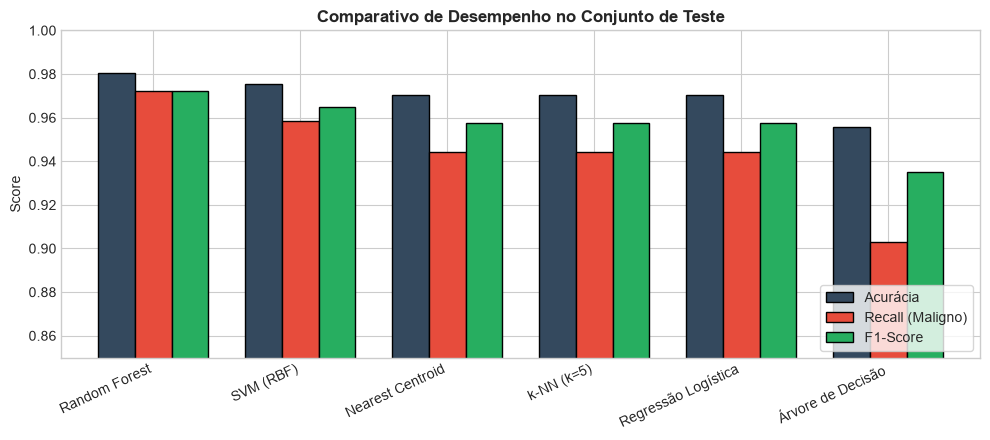

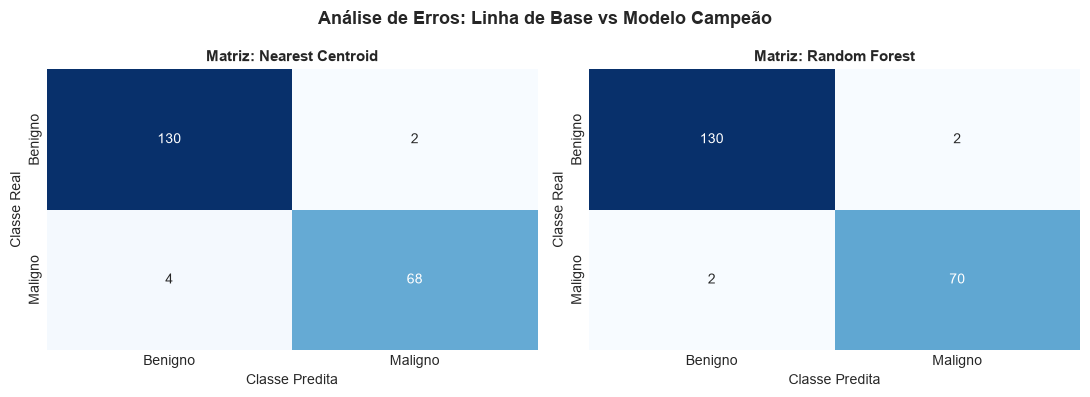

In [8]:
# 1. Gráfico de Barras Comparativo
fig, ax = plt.subplots(figsize=(10, 4.5))
df_results[["Acurácia", "Recall (Maligno)", "F1-Score"]].plot(
    kind="bar", 
    ax=ax, 
    color=["#34495e", "#e74c3c", "#27ae60"], 
    edgecolor="black", 
    width=0.75
)
ax.set_title("Comparativo de Desempenho no Conjunto de Teste", fontweight="bold", fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.set_xticklabels(df_results.index, rotation=25, ha="right")
ax.legend(frameon=True, facecolor="white", loc="lower right")
plt.show()

# 2. Matrizes de Confusão (Nearest Centroid vs Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comparar = ["Nearest Centroid", "Random Forest"]

for ax, nome in zip(axes, comparar):
    cm = confusion_matrix(y_test, predictions[nome])
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=False, 
        ax=ax,
        xticklabels=class_labels, 
        yticklabels=class_labels
    )
    ax.set_title(f"Matriz: {nome}", fontweight="bold", fontsize=11)
    ax.set_ylabel("Classe Real")
    ax.set_xlabel("Classe Predita")

plt.suptitle("Análise de Erros: Linha de Base vs Modelo Campeão", fontsize=13, fontweight="bold")
plt.show()

## 7. Análise de Fronteiras e Importância de Features
- **Projeção 2D com PCA**: Exibe o plano de separabilidade e a geometria da fronteira linear do *Nearest Centroid* versus a flexibilidade do *k-NN*.
- **Feature Importance (Gini)**: Apresenta as variáveis citológicas mais determinantes na predição do *Random Forest*.

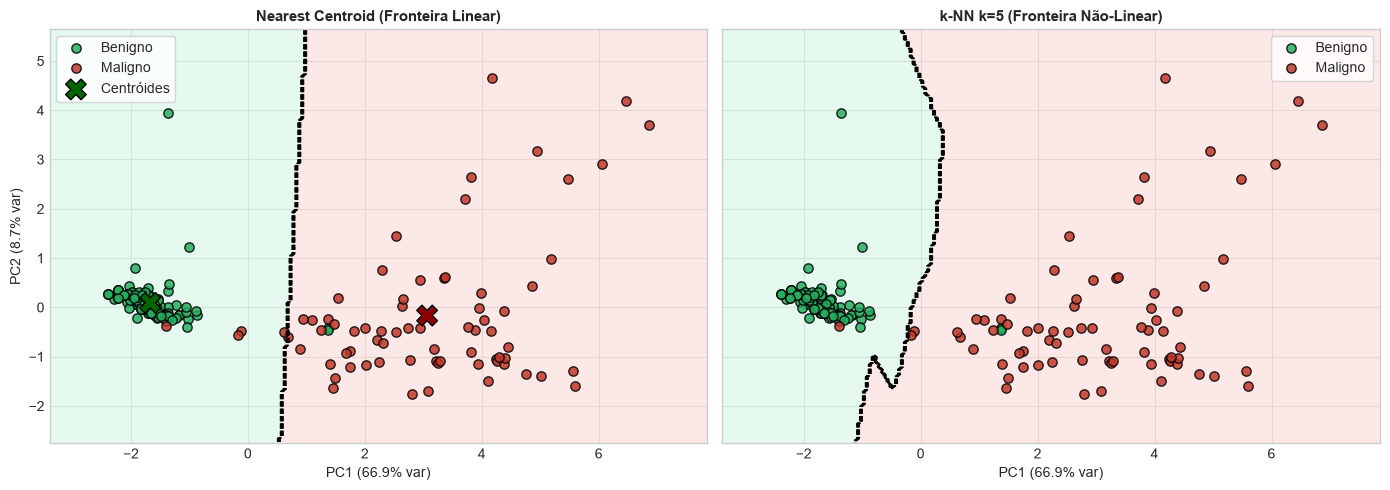

In [9]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

clf_centroid_2d = NearestCentroid().fit(X_test_pca, y_test)
clf_knn_2d = KNeighborsClassifier(n_neighbors=5).fit(X_test_pca, y_test)

# Malha de densidade para fronteira
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

cmap_light = ListedColormap(["#d5f5e3", "#fadbd8"])
colors_pts = {0: "#27ae60", 1: "#c0392b"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
modelos_2d = [("Nearest Centroid (Fronteira Linear)", clf_centroid_2d, axes[0]),
              ("k-NN k=5 (Fronteira Não-Linear)", clf_knn_2d, axes[1])]

for title, model, ax in modelos_2d:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    ax.contour(xx, yy, Z, colors="black", linewidths=1.0, linestyles="--")
    
    for cls_id, label in enumerate(class_labels):
        mask = y_test == cls_id
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                   c=colors_pts[cls_id], label=label, edgecolors="k", s=45, alpha=0.85)
        
    if isinstance(model, NearestCentroid):
        ax.scatter(model.centroids_[:, 0], model.centroids_[:, 1],
                   c=["darkgreen", "darkred"], marker="X", s=220, edgecolors="black", label="Centróides")
        
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.legend(frameon=True, facecolor="white")

axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.show()

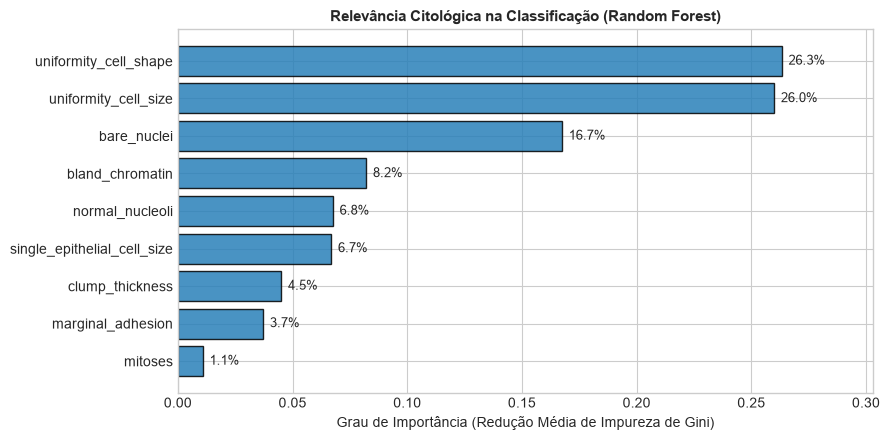

In [10]:
rf_clf = classifiers["Random Forest"]
importancias = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(9, 4.5))
bars = plt.barh(importancias.index, importancias.values, color="#2980b9", edgecolor="black", alpha=0.85)
plt.title("Relevância Citológica na Classificação (Random Forest)", fontsize=11, fontweight="bold")
plt.xlabel("Grau de Importância (Redução Média de Impureza de Gini)")

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.003, bar.get_y() + bar.get_height() / 2, f"{w*100:.1f}%", va="center", fontsize=9)

plt.xlim(0, max(importancias.values) + 0.04)
plt.show()

## 8. Conclusões e Considerações Clínicas
1. **Desempenho Geral:** O modelo ensemble **Random Forest** obteve o melhor equilíbrio global, atingindo **98,04% de Acurácia** e minimizando os casos críticos com **97,22% de Sensibilidade/Recall** para tumores malignos (apenas 2 falsos negativos em 72).
2. **Eficiência do Baseline (*Nearest Centroid*):** Apesar de sua premissa geométrica simples de centróides médios e fronteira linear, atingiu **97,06% de acurácia**, demonstrando que os dados transformados por PCA apresentam forte separabilidade linear.
3. **Features Mais Críticas:** As métricas celulares de `uniformity_cell_size` e `bare_nuclei` foram as mais determinantes para identificar malignidade na abordagem por árvores.